## Lorenz Attractor Equations



$$
\frac{dx}{dt}
=
\sigma (y-x)
$$

$$
\frac{dy}{dt}
=
x(\rho-z)-y
$$

$$
\frac{dz}{dt}
=
xy-\beta z
$$

where

- $x$ = convective motion variable  
- $y$ = temperature-related variable  
- $z$ = vertical temperature profile variable  

---

Parameters:

- $\sigma$ = Prandtl number  
- $\rho$ = control (Rayleigh-like) parameter  
- $\beta$ = geometric parameter

Typical classical values:

$$
\sigma = 10
$$

$$
\rho = 28
$$

$$
\beta = \frac{8}{3}
$$

---

### Interpretation

$$
\sigma(y-x)
$$

couples $x$ and $y$.

---

$$
x(\rho-z)-y
$$

contains nonlinear coupling through $xz$.

---

$$
xy-\beta z
$$

contains nonlinear coupling through $xy$.

---

These nonlinear terms produce sensitive dependence on initial conditions and chaotic motion.

The trajectory forms the Lorenz attractor.

In [41]:
import numpy as np
import matplotlib.pyplot as plt



In [42]:
sigma = 10
rho = 28
beta = 8/3

dt = 0.01
tmax = 50

x0 = 1
y0= 1
z0= 1



In [43]:
def lorenz():
    xlist=[]
    ylist=[]
    zlist=[]
    x=x0
    y=y0
    z=z0
    t=0
    while t<tmax:
        xlist.append(x)
        ylist.append(y)
        zlist.append(z)
        vx = sigma*(y-x)
        vy = x*(rho-z)-y
        vz = x*y-beta*z
        x = x + dt*dx
        y = y + dt*dy
        z = z + dt*dz
        t = t + dt
    return xlist, ylist, zlist

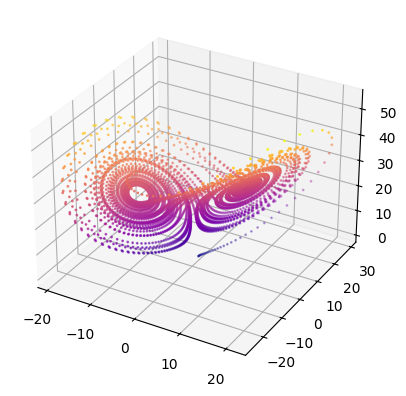

In [47]:
x,y,z=lorents()

ax=plt.axes(projection='3d')

ax.scatter(x,y,z,c=z,cmap='plasma',s=1)

plt.show()

# Epidemic Modeling Notes 

Includes detailed explanations of variables, parameters, ranges, significance, and Jupyter $$ equations.

## State Variables

$$0 \le S,I,R,E,Q \le N$$

- $S$ susceptible  
- $E$ exposed  
- $I$ infected  
- $Q$ quarantined  
- $R$ recovered  
- $D$ cumulative disease deaths

Basic conservation:

$$N=S+I+R$$

Extended:

$$N=S+E+I+Q+R$$


## Parameters

### Transmission

$$\beta=cp$$

Typical safer modeling range:

$$0.05 \le \beta \le 0.8$$

Important:

$$\beta=1.5$$

does NOT mean entire population infected in one day.

Actual infections depend on

$$\beta \frac{SI}{N}$$

### Recovery

$$\gamma=\frac{1}{T_{infectious}}$$

Typical:

$$0.05 \le \gamma \le 0.5$$

### Other Parameters

$$0 \le v \le 0.1$$

$$0 \le s,m \le 1$$

$$0 \le q \le 0.5$$

$$0.1 \le \sigma \le 1$$

$$0 \le \delta \le 0.1$$

$$0 \le \omega \le 0.05$$

### Reproduction Number

$$R_0=\frac{\beta}{\gamma}$$


In [48]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Basic SIR

$$\frac{dS}{dt}=-\beta \frac{SI}{N}$$

$$\frac{dI}{dt}=\beta \frac{SI}{N}-\gamma I$$

$$\frac{dR}{dt}=\gamma I$$


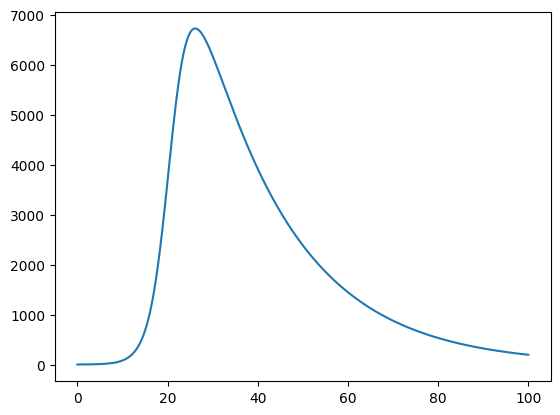

In [67]:
beta=0.5
gamma=0.05
N0=10000
dt=0.1
tmax=100
S=9999
I=1
R=0
t=0
tlist=[]
Ilist=[]
while t<tmax:
    N=N0
    tlist.append(t)
    Ilist.append(I)
    dS=-beta*S*I/N
    dI=beta*S*I/N-gamma*I
    dR=gamma*I
    S=S+dt*dS
    I=I+dt*dI
    R=R+dt*dR
    t+=dt
plt.plot(tlist,Ilist)
plt.show()


## Extended Model

This model adds interventions and biological effects to the basic epidemic model.

### Effective transmission

$$
\beta_{eff}=(1-s)(1-m)\beta
$$

where

- $\beta$ = baseline transmission rate  
- $s$ = social distancing strength  
- $m$ = mask effectiveness  

The factors $(1-s)$ and $(1-m)$ reduce transmission due to fewer contacts and reduced infection probability.

---

### Susceptible

$$
\frac{dS}{dt}
=
-\beta_{eff}\frac{SI}{N}
-vS
+\omega R
$$

- $-\beta_{eff}\frac{SI}{N}$ : susceptible become infected  
- $-vS$ : susceptible leave through vaccination  
- $+\omega R$ : recovered lose immunity and return to susceptible  

---

### Exposed

$$
\frac{dE}{dt}
=
\beta_{eff}\frac{SI}{N}
-\sigma E
$$

- $+\beta_{eff}\frac{SI}{N}$ : new infections enter exposed group  
- $-\sigma E$ : exposed become infectious  

---

### Infected

$$
\frac{dI}{dt}
=
\sigma E
-(\gamma+\delta+q)I
$$

- $+\sigma E$ : exposed become infected  
- $-\gamma I$ : recovery  
- $-\delta I$ : disease deaths  
- $-qI$ : quarantine removes infected  

---

Parameters:

- $\gamma$ = recovery rate  
- $\delta$ = mortality rate  
- $q$ = quarantine rate  
- $\sigma$ = incubation rate  
- $\omega$ = immunity loss rate

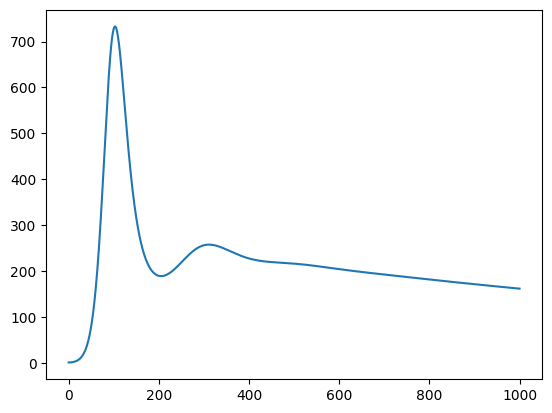

In [68]:
tmax=1000
s=0.2
m=0.0
v=0.01
q=0.05
sigma=0.2
delta=0.02
omega=0.01
beta_eff=(1-s)*(1-m)*beta
S=9999
E=0
I=1
Q=0
R=0
D=0
t=0
tlist=[]
Ilist=[]
while t<tmax:
    tlist.append(t)
    Ilist.append(I)
    N=N0-D
    dS=-beta_eff*S*I/N-v*S+omega*R
    dE=beta_eff*S*I/N-sigma*E
    dI=sigma*E-(gamma+delta+q)*I
    dQ=q*I-gamma*Q
    dR=gamma*I+gamma*Q+v*S-omega*R
    dD=delta*I
    S=S+dt*dS
    E=E+dt*dE
    I=I+dt*dI
    Q=Q+dt*dQ
    R=R+dt*dR
    D=D+dt*dD
    t+=dt
plt.plot(tlist,Ilist)
plt.show()
